In [1]:
import subprocess
import sys, os

#### If running on ROOT casa image some packages necessary for opening our files and plotting are not installed

def install_package(package_name):
    # Install the package using subprocess to call pip
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

def import_packages():
    try:
        import mplhep  # Replace with the module name of the package
    except ImportError:
        print(f"{'mplhep'} not found. Installing...")
        install_package("mplhep")
        import mplhep  # Import again after installation
    try:
        import hist  # Replace with the module name of the package
    except ImportError:
        print(f"{'hist'} not found. Installing...")
        install_package("hist")
        import hist  # Import again after installation
    try:
        import coffea  # Replace with the module name of the package
    except ImportError:
        print(f"{'coffea'} not found. Installing...")
        install_package("coffea==0.7.22")
        import coffea  # Import again after installation
        
        
import_packages()

In [2]:
import pickle as pkl
import numpy as np 
import hist
from collections import defaultdict


In [3]:
# def group(h: hist.Hist, oldname: str, newname: str, grouping: dict[str, list[str]]):
#     hnew = hist.Hist(
#         hist.axis.StrCategory(grouping, name=newname),
#         *(ax for ax in h.axes if ax.name != oldname),
#         storage=h.storage_type,
#     )
#     for i, indices in enumerate(grouping.values()):
#         hnew.view(flow=True)[i] = h[{oldname: indices}][{oldname: sum}].view(flow=True)

#     return hnew

In [4]:
keymap = {
    "2016": "pythia_UL16NanoAODv9",
    "2016APV": "pythia_UL16NanoAODAPVv9",
    "2017": "pythia_UL17NanoAODv9",
    "2018": "pythia_UL18NanoAODv9",
}
filename = "../../coffeaOutput/dijetHists_wXS_HTplots_QCDsim_MG__allUncALLRespOnly.pkl"
with open(filename, "rb") as f:
        data = pkl.load(f)
filename = "../../coffeaOutput/dijetHists_wXS_HTplots_QCDsim_herwig__allUncALLRespOnly.pkl"
with open(filename, "rb") as f:
        output_herwig = pkl.load(f)


print(data['response_matrix_u'].axes)

(StrCategory(['QCD_pythiaMG2016APV', 'QCD_pythiaMG2016', 'QCD_pythiaMG2017', 'QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'), StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown', 'JERUp', 'JERDown', 'HEM', 'JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown', 'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp', 'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown', 'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up', 'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_RelativeJEREC2Dow

In [5]:
# grouping = defaultdict(list)
# grouping[new_key].append(ds)
# h = group(h, oldname="dataset", newname="dataset", grouping=dict(grouping))

In [6]:
correlation_dic = {
    'JES_AbsoluteMPFBias': 1,
    'JES_AbsoluteScale': 1,
    'JES_AbsoluteStat': 0,
    'JES_FlavorQCD': 1,
    'JES_Fragmentation': 1,
    'JES_PileUpDataMC': 0.5,
    'JES_PileUpPtBB': 0.5,
    'JES_PileUpPtEC1': 0.5,
    'JES_PileUpPtEC2': 0.5,
    'JES_PileUpPtHF': 0.5,
    'JES_PileUpPtRef': 0.5,
    'JES_RelativeFSR': 0.5,
    'JES_RelativeJEREC1': 0,
    'JES_RelativeJEREC2': 0,
    'JES_RelativeJERHF': 0.5,
    'JES_RelativePtBB': 0.5,
    'JES_RelativePtEC1': 0,
    'JES_RelativePtEC2': 0,
    'JES_RelativePtHF': 0.5,
    'JES_RelativeBal': 0.5,
    'JES_RelativeSample': 0,
    'JES_RelativeStatEC': 0,
    'JES_RelativeStatFSR': 0,
    'JES_RelativeStatHF': 0,
    'JES_SinglePionECAL': 1,
    'JES_SinglePionHCAL': 1,
    'JES_TimePtEta': 0,
    'JER': 0,
}

jes_sys_list = ['JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown',
                'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp',
                'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown',
                'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 
                'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up',
                'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_RelativeJEREC2Down', 'JES_RelativeJERHFUp', 'JES_RelativeJERHFDown',
                'JES_RelativePtBBUp', 'JES_RelativePtBBDown', 'JES_RelativePtEC1Up', 'JES_RelativePtEC1Down', 'JES_RelativePtEC2Up', 'JES_RelativePtEC2Down',
                'JES_RelativePtHFUp', 'JES_RelativePtHFDown', 'JES_RelativeBalUp', 'JES_RelativeBalDown', 'JES_RelativeSampleUp', 'JES_RelativeSampleDown', 
                'JES_RelativeStatECUp', 'JES_RelativeStatECDown', 'JES_RelativeStatFSRUp', 'JES_RelativeStatFSRDown', 'JES_RelativeStatHFUp', 'JES_RelativeStatHFDown',
                'JES_SinglePionECALUp', 'JES_SinglePionECALDown', 'JES_SinglePionHCALUp', 'JES_SinglePionHCALDown', 'JES_TimePtEtaUp', 'JES_TimePtEtaDown', 'JERUp', 'JERDown']


non_jes_sys_list = ['LuminosityUp','LuminosityDown','PDFDown', 'PDFUp', 'L1prefiringDown', 'L1prefiringUp', 'Q2muRUp','Q2muRDown','PUSFUp', 'Q2muFUp','Q2muFDown', 'PUSFDown', "JMRUp", "JMRDown", "JMSUp", "JMSDown"]

non_jes_sys_list_up = [sys for sys in non_jes_sys_list if sys[-2:] == 'Up' ]
non_jes_sys_list_down = [sys for sys in non_jes_sys_list if sys[-4:] == 'Down' ]

jes_sys_list_up = [sys for sys in jes_sys_list if sys[-2:] == 'Up' ]
jes_sys_list_down = [sys for sys in jes_sys_list if sys[-4:] == 'Down' ]

In [7]:
# sys_matrix_dic_up = {}
# sys_matrix_var_dic_up = {}
# sys_matrix_dic_down = {}
# sys_matrix_var_dic_down = {}
# non_jes_sys_matrix_dic_up = {}
# non_jes_sys_matrix_dic_down = {}
# groomed = True
# if not groomed:
#     response = data['response_matrix_u']
# else:
#     response = data['response_matrix_g']
# mcstring='QCD_pythiaMG'
# for sys in jes_sys_list_up:
#     # keep both values() and variances() — do not compute variances manually or apply correlations here
#     # nominal: values + variances per year
#     m_nom_2016 = response[{"syst":'nominal', "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2016_var = response[{"syst":'nominal', "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     #### add APV
#     m_nom_2017 = response[{"syst":'nominal', "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2017_var = response[{"syst":'nominal', "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_nom_2018 = response[{"syst":'nominal', "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2018_var = response[{"syst":'nominal', "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()

#     # systematic: values + variances per year
#     m_sys_2016 = response[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2016_var = response[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     #### add APV
#     m_sys_2017 = response[{"syst":'nominal', "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2017_var = response[{"syst":'nominal', "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_sys_2018 = response[{"syst":'nominal', "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2018_var = response[{"syst":'nominal', "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()


    
#     # combine years by summing (keep values and variances separate)
#     m_nom_vals = m_nom_2016 + m_nom_2017 + m_nom_2018
#     m_nom_vars = m_nom_2016_var + m_nom_2017_var + m_nom_2018_var

#     m_sys_vals = m_sys_2016 + m_sys_2017 + m_sys_2018
#     m_sys_vars = m_sys_2016_var + m_sys_2017_var + m_sys_2018_var

#     # store both representations; keep original-named m_nom_2016/2017/2018 (values) so later code that sums them continues to work
#     sys_matrix_dic_up[sys] = m_sys_vals
#     sys_matrix_var_dic_up[sys] = m_sys_vars
#     sys_matrix_dic_up[sys + '_nom_vals'] = m_nom_vals
#     sys_matrix_var_dic_up[sys + '_nom_vars'] = m_nom_vars

#     non_jes_sys_matrix_dic_up[sys + '_vals'] = m_sys_vals
#     non_jes_sys_matrix_dic_up[sys + '_vars'] = m_sys_vars
#     variation = variation16 + variation17 + variation18
#     sys_matrix_dic_down[sys] = variation
#     non_jes_sys_matrix_dic_down[sys] = variation
# m_nom = m_nom_2016 + m_nom_2017 + m_nom_2018

# # sys_matrix_dic['herwigUp'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()
# # sys_matrix_dic_down['herwigDown'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()

In [23]:
sys_matrix_dic_up = {}

groomed = False
if not groomed:
    response = data['response_matrix_u']
    resp_matrix_4d_herwig  = output_herwig['response_matrix_u'][{'syst':"nominal"}]
else:
    response = data['response_matrix_g']
    resp_matrix_4d_herwig  = output_herwig['response_matrix_g'][{'syst':"nominal"}]
mcstring='QCD_pythiaMG'

print(resp_matrix_4d_herwig, response[{"syst":'nominal'}])
for sys in jes_sys_list_up:
    
    m_nom_2016 = response[{"syst":'nominal', "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2016_var = response[{"syst":'nominal', "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
    #### add APV
    m_nom_2017 = response[{"syst":'nominal', "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2017_var = response[{"syst":'nominal', "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
    m_nom_2018 = response[{"syst":'nominal', "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2018_var = response[{"syst":'nominal', "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()

    variance = m_nom_2016_var+m_nom_2017_var+m_nom_2018_var
    
    m_sys_2016 = response[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    #### add APV
    m_sys_2017 = response[{"syst":sys, "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2018 = response[{"syst":sys, "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()

    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = correlation_dic[sys[:-2]] ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_up[sys+'_corr'] = m_corr
    sys_matrix_dic_up[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_up[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_up[sys+'_uncorr_2018'] = m_uncorr_2018
    
non_jes_sys_matrix_dic_up = {}
for sys in non_jes_sys_list_up:
    sys_matrix_dic_up[sys] = response[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response[{"syst":sys, "dataset":mcstring+'2017'}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response[{"syst":sys, "dataset":mcstring+'2018'}].project('ptgen','mgen','ptreco','mreco').values()
#                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values
    non_jes_sys_matrix_dic_up[sys] = response[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response[{"syst":sys, "dataset":mcstring+'2017'}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response[{"syst":sys, "dataset":mcstring+'2018'}].project('ptgen','mgen','ptreco','mreco').values()



sys_matrix_dic_down = {}
non_jes_sys_matrix_dic_down = {}
for sys in jes_sys_list_down:
    m_nom_2016 = response[{"syst":'nominal', "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2017 = response[{"syst":'nominal', "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2018 = response[{"syst":'nominal', "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    m_sys_2016 = response[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2017 = response[{"syst":sys, "dataset":mcstring+'2017'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2018 = response[{"syst":sys, "dataset":mcstring+'2018'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    rho = correlation_dic[sys[:-4]] ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_down[sys+'_corr'] = m_corr
    sys_matrix_dic_down[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_down[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_down[sys+'_uncorr_2018'] = m_uncorr_2018
    

for sys in non_jes_sys_list_down:
    sys_matrix_dic_down[sys] = response[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response[{"syst":sys, "dataset":mcstring+'2017'}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response[{"syst":sys, "dataset":mcstring+'2018'}].project('ptgen','mgen','ptreco','mreco').values()
#                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values
    non_jes_sys_matrix_dic_down[sys] = response[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response[{"syst":sys, "dataset":mcstring+'2017'}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response[{"syst":sys, "dataset":mcstring+'2018'}].project('ptgen','mgen','ptreco','mreco').values()


herwig_diff = np.abs(resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values() - response[{"syst":"nominal"}].project('ptgen','mgen','ptreco','mreco').values())
sys_matrix_dic_down['herwigDown'] = response[{"syst":"nominal"}].project('ptgen','mgen','ptreco','mreco').values() - herwig_diff
sys_matrix_dic_up['herwigUp'] = response[{"syst":"nominal"}].project('ptgen','mgen','ptreco','mreco').values() + herwig_diff

Hist(
  StrCategory(['QCD_herwig2016APV', 'QCD_herwig2016', 'QCD_herwig2017', 'QCD_herwig2018'], growth=True, name='dataset', label='Primary dataset'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptgen', label='$p_{T,GEN}$ [GeV]'),
  Variable([0, 5, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 900, 1300], name='mgen', label='$m_{GEN}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=1.01523e+10, var

In [24]:
sys_matrix_dic_up['nominal'] = m_nom
sys_matrix_dic_down['nominal'] = m_nom

In [25]:
sys_matrix_dic_up.keys()

dict_keys(['JES_AbsoluteMPFBiasUp_corr', 'JES_AbsoluteMPFBiasUp_uncorr_2016', 'JES_AbsoluteMPFBiasUp_uncorr_2017', 'JES_AbsoluteMPFBiasUp_uncorr_2018', 'JES_AbsoluteScaleUp_corr', 'JES_AbsoluteScaleUp_uncorr_2016', 'JES_AbsoluteScaleUp_uncorr_2017', 'JES_AbsoluteScaleUp_uncorr_2018', 'JES_AbsoluteStatUp_corr', 'JES_AbsoluteStatUp_uncorr_2016', 'JES_AbsoluteStatUp_uncorr_2017', 'JES_AbsoluteStatUp_uncorr_2018', 'JES_FlavorQCDUp_corr', 'JES_FlavorQCDUp_uncorr_2016', 'JES_FlavorQCDUp_uncorr_2017', 'JES_FlavorQCDUp_uncorr_2018', 'JES_FragmentationUp_corr', 'JES_FragmentationUp_uncorr_2016', 'JES_FragmentationUp_uncorr_2017', 'JES_FragmentationUp_uncorr_2018', 'JES_PileUpDataMCUp_corr', 'JES_PileUpDataMCUp_uncorr_2016', 'JES_PileUpDataMCUp_uncorr_2017', 'JES_PileUpDataMCUp_uncorr_2018', 'JES_PileUpPtBBUp_corr', 'JES_PileUpPtBBUp_uncorr_2016', 'JES_PileUpPtBBUp_uncorr_2017', 'JES_PileUpPtBBUp_uncorr_2018', 'JES_PileUpPtEC1Up_corr', 'JES_PileUpPtEC1Up_uncorr_2016', 'JES_PileUpPtEC1Up_uncorr_2

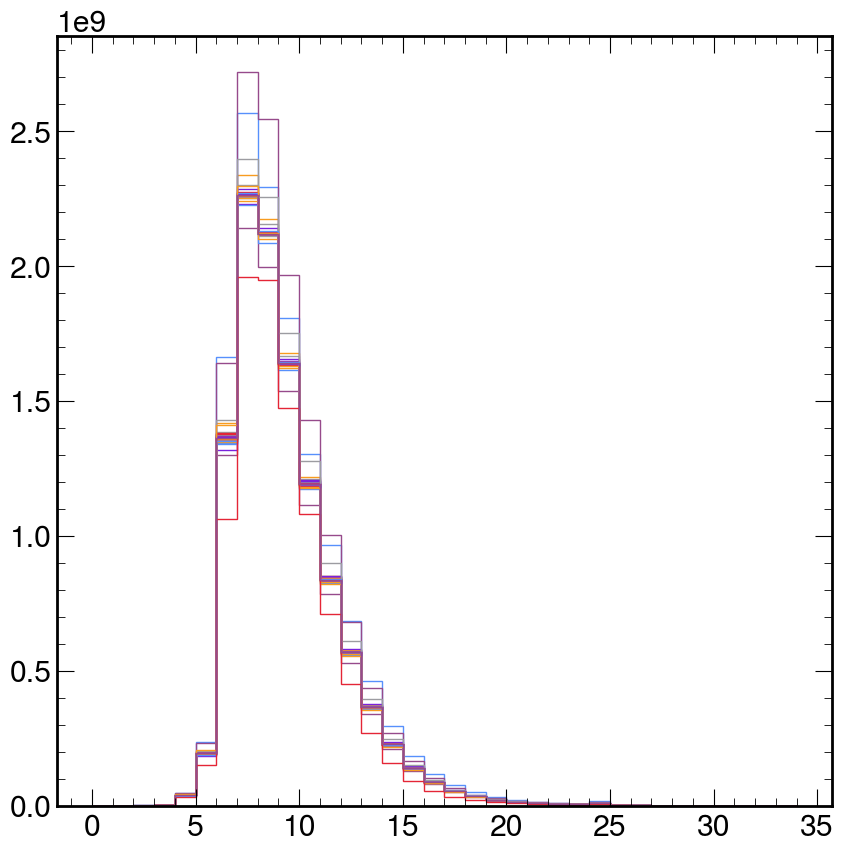

In [26]:
import matplotlib.pyplot as plt
for key in sys_matrix_dic_up.keys():
    plt.stairs(sys_matrix_dic_up[key].sum(axis = (0,1,2)), label=key)
for key in sys_matrix_dic_down.keys():
    plt.stairs(sys_matrix_dic_down[key].sum(axis = (0,1,2)), label=key)

# plt.yscale('log')
# plt.ylim(1e8, 1e9)

In [27]:
import os
out_dir = "../inputs/"  # uses the existing "./inputs/" variable
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "sys_matrix_dic.pkl")

# merge up and down into a single dict, avoid double-counting 'nominal'
merged = dict(sys_matrix_dic_up)  # shallow copy of up
for k, v in sys_matrix_dic_down.items():
    if k == "nominal":
        continue  # skip duplicate nominal from the down dict
    if k in merged:
        # if a key collides, store the down version with a suffix
        merged_key = f"{k}_down"
        # ensure uniqueness
        i = 1
        unique_key = merged_key
        while unique_key in merged:
            unique_key = f"{merged_key}_{i}"
            i += 1
        merged[unique_key] = v
    else:
        merged[k] = v

with open(out_path, "wb") as f:
    pkl.dump(merged, f, protocol=4)

print(f"Saved {out_path} with {len(merged)} entries")

Saved ../inputs/sys_matrix_dic.pkl with 243 entries


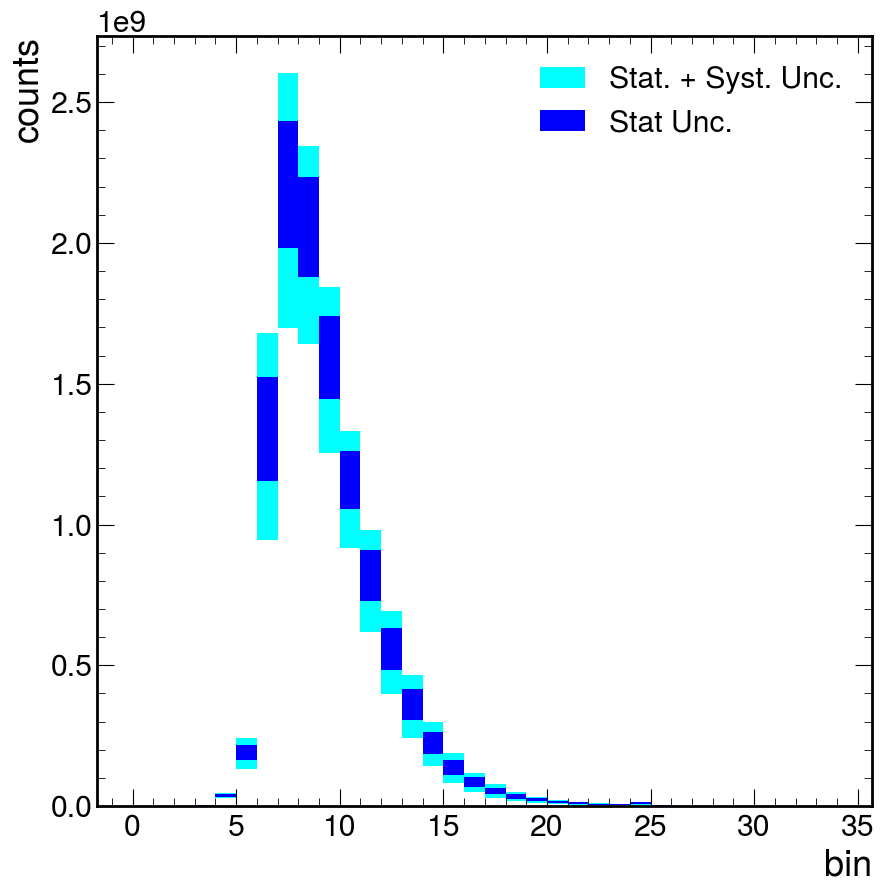

In [28]:
import matplotlib.pyplot as plt
import hist
import mplhep as hep

mreco_nom = m_nom.sum(axis = (0,1,2))
total_unc_up = np.zeros_like(mreco_nom)
for key in sys_matrix_dic_up.keys():
    mreco_sys = sys_matrix_dic_up[key].sum(axis = (0,1,2))
    delta = mreco_sys - mreco_nom
    total_unc_up += delta**2
total_unc_up = np.sqrt(total_unc_up)
total_unc_down = np.zeros_like(mreco_nom)
for key in sys_matrix_dic_down.keys():
    mreco_sys = sys_matrix_dic_down[key].sum(axis = (0,1,2))
    delta = mreco_sys - mreco_nom
    total_unc_down += delta**2
total_unc_down = np.sqrt(total_unc_down)
bins = np.arange(len(mreco_nom) + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.style.use(hep.style.CMS)  # optional styling
fig, ax = plt.subplots()
hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_unc_down, total_unc_up], label='Stat. + Syst. Unc.',ax=ax, facecolor = 'cyan', hatch = '', alpha = 1)
hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_unc_down/2, total_unc_up/2], label='Stat Unc.',ax=ax, facecolor = 'blue', hatch = '', alpha = 1)
#ax.errorbar(bin_centers, mreco_nom, yerr=[total_unc_down, total_unc_up], fmt='none', color='black', label='total uncertainty')
# ax.set_yscale('log')
ax.set_xlabel('bin')
ax.set_ylabel('counts')
ax.legend()